## DSAN 5650 Week 6 Coding Workshop: Selective Transmission of Historical Documents

### Loading and Exploring the Data

This question is going to feel a bit "in the weeds" at first -- because it is -- but points to the importance of the [library of missing datasets](https://github.com/MimiOnuoha/missing-datasets) which lurks behind any actually-existing dataset you may find! It also relates to Berkson's Paradox, which will be the subject of Part 2 below.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pymc as pm

In [9]:
pub_url = "https://raw.githubusercontent.com/jpowerj/dsan-content/refs/heads/main/2025-sum-dsan5650/cahiers_official.csv"
pub_df = pd.read_csv(pub_url)
pub_df.head()

,village_name,published,huguenot
0,ARRAS (ARTOIS),True,False
1,"AURAY, REUNI A VANNES (SEN)",True,False
2,AUTUN,True,True
3,"BOULAY, REUNI A SARREGUEMINES",True,True
4,CALAIS,True,False


As the following cell shows, there were 32 villages whose *cahiers* were deemed "exemplary" of the grievances of France as a whole:

In [10]:
len(pub_df)

32

And, as the following cell makes clear, over 40% of these "exemplary" *cahiers* contained grievances about the treatment of French Protestants (Huguenots):

In [11]:
pub_df['huguenot'].value_counts(normalize=True)

huguenot
False    0.59375
True     0.40625
Name: proportion, dtype: float64

### [Question 1.1] Modeling the Published Documents

In the following code cell, use PyMC to create a generative model of the published *cahiers* as follows:

* First, the model should include a variable `p_hug`, representing the overall probability that a given *cahier* contains a grievance related to treatment of Huguenots
* Then, the model should include a *village-specific* variable `huguenot`, a binary variable which has the value 1 for villages whose cahier contains a grievance related to treatment of Huguenots, and 0 for villages whose cahier does not contain such a grievance.

`p_hug` and `huguenot` should be **linked** such that the probability of `huguenot` taking the value 1 is exactly `p_hug` -- the included line of code at the end of the cell prints the model as a PGM, where there should be an arrow from the `p_hug` node to the `huguenot` node!

In [12]:
village_idx, village_name = pub_df['village_name'].factorize()
print(village_idx)
print(village_name)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31]
Index(['ARRAS (ARTOIS)', 'AURAY, REUNI A VANNES (SEN)', 'AUTUN',
       'BOULAY, REUNI A SARREGUEMINES', 'CALAIS', 'CARCASSONNE',
       'CARIGNAN, REUNI A SEDAN', 'CHATEAU-SALINS, REUNI A SARREGUEMINES',
       'COMMINGES', 'COUTANCES, BAILLIAGE PRINCIPALE',
       'DIGNE, REUNI A FORCALQUIER', 'DOLE', 'DRAGUIGNAN, CENTRE DE REUNION',
       'FORCALQUIER, CENTRE DE REUNION', 'LAMARCHE, REUNI A BAR-LE-DUC',
       'LIMOGES', 'LONGWY, REUNI A METZ (BAILL)', 'LUNEVILLE, REUNI A NANCY',
       'MELUN', 'MONTREUIL-SUR-MER', 'NANCY, CENTRE DE REUNION', 'PAMIERS',
       'PARIS (HORS-LES-MURS)', 'REIMS', 'SARRELOUIS, REUNI A METZ (BAILL)',
       'SAUMUR', 'SENLIS', 'SENS', 'THIAUCOURT, REUNI A BAR-LE-DUC',
       'TOULON, CENTRE DE REUNION', 'VERDUN, CENTRE DE REUNION',
       'VILLEFRANCHE (BEAUJOLAIS)'],
      dtype='str')


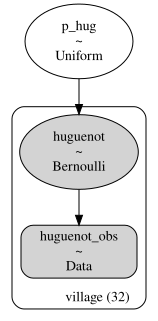

In [58]:
# @title Q1.1-response
pub_coords = {
  'village': village_name
}
with pm.Model(coords=pub_coords) as pub_model:
  # Your code here: model the two random variables p_hug and huguenot as
  # described above
  huguenot_obs = pm.Data('huguenot_obs', pub_df['huguenot'], dims='village')
  p_hug = pm.Uniform('p_hug', lower=0, upper=1)
  huguenot = pm.Bernoulli('huguenot', p=p_hug, observed=huguenot_obs, dims='village')
  # p_hug = 

if pub_model is not None:
  display(pm.model_to_graphviz(pub_model))

### [Question 1.2] Sampling from the Prior Distribution

Now, in the following code cell, sample from the **prior predictive** distribution using PyMC's `sample_prior_predictive()` function, storing the result in a variable named `pub_prior_idata`. Once this variable is created correctly, the remaining provided code will construct a Pandas `DataFrame` and plot the distribution of `p_hug`:

In [59]:
# @title Q1.2-response
# Your code here: create a variable pub_prior_idata containing the predictive prior
# distribution
pub_prior_idata = pm.sample(model=pub_model)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_hug]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [60]:
pub_prior_idata

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:  (chain: 4, draw: 1000)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│       Data variables:
│           p_hug    (chain, draw) float64 32kB 0.3183 0.4156 0.4156 ... 0.4611 0.3133
│       Attributes:
│           created_at:                 2026-06-26T21:17:40.865234+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.0
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              1.2376618385314941
│           tuning_steps:               1000
├── Group: /sample_stats
│       Dimensions:                (chain: 4, draw: 1000)
│       Coordinates:
│         * chain                  (chain) int64 32B 0 1 2 3
│         * draw                   (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
│       Data variables: (12/18)
│           smallest_eigval        (chain, draw) float64 32kB nan nan nan ... nan nan
│           largest_eigval         (chain, draw) float64 32kB nan nan nan ... nan nan
│           energy_error           (chain, draw) float64 32kB 0.247 -0.4806 ... 0.3735
│           index_in_trajectory    (chain, draw) int64 32kB -1 -2 0 2 2 ... 1 1 -2 -1 2
│           perf_counter_start     (chain, draw) float64 32kB 3.231e+05 ... 3.231e+05
│           perf_counter_diff      (chain, draw) float64 32kB 0.0001455 ... 0.0002084
│           ...                     ...
│           max_energy_error       (chain, draw) float64 32kB 0.247 1.372 ... 2.787
│           reached_max_treedepth  (chain, draw) bool 4kB False False ... False False
│           process_time_diff      (chain, draw) float64 32kB 0.0001457 ... 0.0002087
│           divergences            (chain, draw) int64 32kB 0 0 0 0 0 0 ... 0 0 0 0 0 0
│           energy                 (chain, draw) float64 32kB 23.72 25.26 ... 25.99
│           n_steps                (chain, draw) float64 32kB 1.0 3.0 3.0 ... 3.0 3.0
│       Attributes:
│           created_at:                 2026-06-26T21:17:40.879321+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.0
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              1.2376618385314941
│           tuning_steps:               1000
├── Group: /observed_data
│       Dimensions:   (village: 32)
│       Coordinates:
│         * village   (village) <U37 5kB 'ARRAS (ARTOIS)' ... 'VILLEFRANCHE (BEAUJOLA...
│       Data variables:
│           huguenot  (village) int64 256B 0 0 1 1 0 0 0 1 0 0 1 ... 1 1 0 0 1 1 0 0 0 1
│       Attributes:
│           created_at:                 2026-06-26T21:17:40.883695+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.0
│           sample_dims:                []
└── Group: /constant_data
        Dimensions:       (village: 32)
        Coordinates:
          * village       (village) <U37 5kB 'ARRAS (ARTOIS)' ... 'VILLEFRANCHE (BEAU...
        Data variables:
            huguenot_obs  (village) bool 32B False False True True ... False False True
        Attributes:
            created_at:                 2026-06-26T21:17:40.884799+00:00
            creation_library:           ArviZ
            creation_library_version:   1.1.0
            creation_library_language:  Python
            inference_library:          pymc
            inference_library_version:  6.0.0
            sample_dims:                []

In [61]:
# Convert to DataFrame
pub_prior_df = pub_prior_idata.posterior.ds.to_dataframe().reset_index().drop(columns="chain")
pub_prior_df

,draw,p_hug
0,0,0.318346
1,1,0.415620
2,2,0.415620
3,3,0.392720
4,4,0.437074
...,...,...
3995,995,0.242635
3996,996,0.333296
3997,997,0.448465
3998,998,0.461109


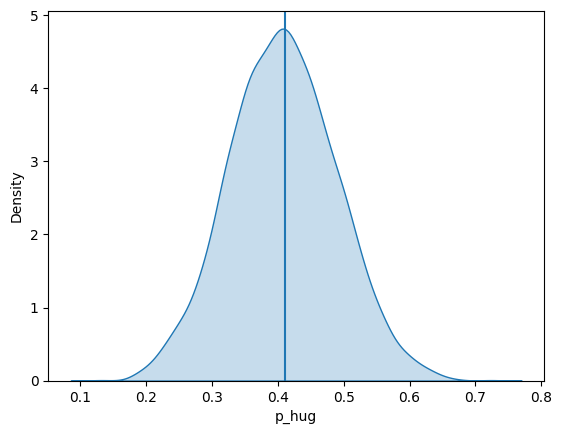

In [62]:


# And plot
sns.kdeplot(
    x="p_hug", data=pub_prior_df, fill=True,
  #binwidth=0.05
);
plt.axvline(0.411)
plt.show()

In [63]:
import arviz as az

az.summary(pub_prior_idata)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
p_hug,0.408,0.081,0.28,0.54,1663,2150,1.00,0.002,0.0014


### Inferring the *Number* of *Cahiers* Containing Huguenot Grievances

If the above code worked as intended, the following code cell should just take the `pub_prior_idata` variable you created and use it to infer the **number** of published cahiers (out of the 32 total that were chosen) containing Huguenot grievances (demonstrating how we can use your model to "jump" to a more coarse-grained level of "cahiers corpus" rather than just individual *cahiers*)

In [ ]:
# @title Q1.2-infer-num-cahiers
pub_prior_pred_df = pub_prior_idata.prior_predictive.to_dataframe().reset_index().drop(columns="chain")
sum_df = pub_prior_pred_df.groupby('draw')['huguenot'].sum().to_frame().reset_index()
sum_df.rename(columns={'huguenot': 'num_huguenot'}, inplace=True)
true_num_hug = len(pub_df[pub_df['huguenot']])

ax = pw.Brick(figsize=(4,2.5));
sns.histplot(
    x="num_huguenot", data=sum_df, ax=ax,
    discrete=True
);
ax.axvline(x=true_num_hug, ls='dashed', color='black', alpha=0.9);
ax.savefig()

### [Question 1.3] Sampling from the Posterior Distribution

Now, let's **estimate** the model parameters using the actual data! In the following code cell, use `sample()` (rather than `sample_prior_predictive()` to draw the actual Bayesian-optimized parameter values, storing the result in a variable named `pub_post_idata`.

If sampled correctly, the plot of the posterior distribution of `p_hug` generated by the included code should be centered around the true value of about 0.4.

In [ ]:
# @title Q1.3-response
# Your code here: use pm.sample() to estimate the *posterior* distribution from
# the data in pub_df

# Convert to DataFrame
pub_post_df = pub_post_idata.posterior.to_dataframe().reset_index()
pub_post_df = pub_post_df.groupby('draw')['p_hug'].mean().to_frame()
# And plot
ax = pw.Brick(figsize=(4, 2.5));
sns.kdeplot(
    x="p_hug", data=pub_post_df, ax=ax,
    fill=True
);
ax.axvline(x=pub_post_df['p_hug'].mean(), lw=1, ls='dashed', alpha=0.9);
ax.savefig()

### [Question 1.4] Sampling from the Posterior Predictive Distribution

Now, drawing on the example code above which performed this coarse-graining on the **prior** predictive distribution (the code cell titled `Q1.2-infer-num-cahiers`), first use PyMC's `sample_posterior_predictive()` function to sample the model's posterior predictive distribution, then use it to generate a plot of the **posterior predictive** distribution of a variable you should name `num_huguenot`: the estimated **number** of *cahiers* mentioning Huguenot grievances given the learned parameters of your model.

In [ ]:
# @title Q1.4-response
with pub_model:
    pub_post_pred_idata = pm.sample_posterior_predictive(pub_post_idata, random_seed=5650)

In [ ]:
pub_post_pred_df = pub_post_pred_idata.posterior_predictive.to_dataframe().reset_index()
pub_post_pred_df = pub_post_pred_df[pub_post_pred_df['chain'] == 0].drop(columns="chain")
pub_post_pred_df

In [ ]:
post_sum_df = pub_post_pred_df.groupby('draw')['huguenot'].sum().to_frame().reset_index()
post_sum_df.rename(columns={'huguenot': 'num_huguenot'}, inplace=True)
post_sum_df

In [ ]:
true_num_hug = len(pub_df[pub_df['huguenot']])

ax = pw.Brick(figsize=(4,2.5));
sns.histplot(
    x="num_huguenot", data=post_sum_df, ax=ax,
    discrete=True
);
ax.axvline(x=true_num_hug, ls='dashed', color='black', alpha=0.9);
ax.savefig()

### [Question 1.5] Accounting for Bias

However, this is where **domain knowledge** can come into play. To condense a long story into a nice neat narrative for this exam (since this is not a class about the French Revolution!), here are four quick stylized facts:

1. A popular interpretation of the French Revolution argues that it was a "bourgeois revolution", meaning that it was in essence the seizure of power by budding capitalists away from the French monarchy.
2. For a bunch of reasons (like their connections with rich Germans who had adopted Protestantism centuries earlier), wealthy Huguenots were seen as possible "replacements" for the Catholic allies whom French Revolutionaries had alienated (e.g., by nationalizing all Church property and forcing Catholic priests to sign an oath of loyalty to the nation of France over Rome). However, many of them had fled in 
3. In addition to the ~700,000 Huguenots, there was a mass [influx of ~40,000 Protestants](https://en.wikipedia.org/wiki/Patriottentijd#Aftermath) from the Netherlands, who were also among the wealthy elites of that country.
4. There was a guy named [Jean-Paul Rabaut](https://en.wikipedia.org/wiki/Jean-Paul_Rabaut_Saint-%C3%89tienne) who you can think of as a "spokesman" for the Huguenot community of France during the crucial first 4 years of the French Revolution (until he was guillotined in 1793). Rabaut put Huguenot rights "on the agenda" as the **president** of the French National Assembly in 1790, and more generally could use his power to put Huguenot

These four facts put together hopefully help motivate the hypothesis that the French Revolutionaries -- especially those involved in shaping the "public image" of the Revolution -- had an interest in **emphasizing the freedom that Protestants now had**. Concretely, this led to the following law passed in December of 1790:

> All persons born in a foreign country and descending in any degree of a French man or woman **expatriated for religious reasons** are declared French nationals (naturels français) and will benefit from rights attached to that quality if they come back to France, establish their domicile there and take the civic oath.

And so, the hypothesis just becomes that: the same collection of people who organized around Huguenot rights to push laws like this into being, also pushed to ensure that **narratives of the French Revolution** such as those **embodied in document collections** would emphasize the Huguenot struggle as much as possible.

Given all this, your job in this part is to **model the possible bias in representation** arising from this push: rather than modeling the distribution $\Pr(\textsf{Huguenot})$ as **independent of** the distribution $\Pr(\textsf{Published})$, you should now model an **inflation factor** representing **how much the proportion of *published cahiers* mentioning Huguenots was inflated (or deflated!) relative to the total collection of *cahiers*.**

In other words, your new model should have a variable named `p_pub_nohug` representing the probability of a *cahier* being published given that it does **not** contain a Huguenot-related grievance, and a variable named `p_pub_hug` representing the probability of a *cahier* that **does** contain a Huguenot-related grievance is published. (If it helps, think about the HW2C problem where you estimated disaster rates before and after a given **change point** -- this problem should be a bit less complex than that, since you don't need to estimate a changepoint in this case, just two separate $\Pr(\textsf{Publish})$ distributions!)

Run the following code cell to load the data for **all** villages, then (a) use the prior-predictive distribution to generate plots of `p_pub_nohug` and `p_pub_hug`

In [ ]:
full_url = "https://raw.githubusercontent.com/jpowerj/dsan-content/refs/heads/main/2025-sum-dsan5650/cahiers_all.csv"
full_df = pd.read_csv(full_url)
full_df.head()

In [ ]:
len(full_df)

In [ ]:
hug_values = full_df['huguenot']
pub_values = full_df['published']
village_idx, village_names = full_df['village_name'].factorize()
coords = {'village': village_idx}
with pm.Model(coords=coords) as infl_model:
    # Your code here: model the probability of publication p_pub *with* and
    # *without* a Huguenot-related grievance, as described above!
    pass # Remove this pass statement once you've started coding your model!
if infl_model is not None:
    display(pm.model_to_graphviz(infl_model))

### [Question 1.6] The Prior Predictive Distribution for `p_pub_nohug` and `p_pub_hug`

As in the published-only case from earlier, derive and plot the prior predictive distributions for these two parameters here. Name the derived prior data `infl_prior_idata`.

In [ ]:
# Your code here: store the prior data for the model as infl_prior_idata

# Convert to DataFrame
infl_prior_df = infl_prior_idata.prior.to_dataframe().reset_index().drop(columns='chain')
# Melt DataFrame to plot both p_pub_nohug and p_pub_hug within the same plot
infl_long_df = infl_prior_df[['draw','village','p_pub_nohug','p_pub_hug']].melt(id_vars=['draw','village'])
# And plot
ax = pw.Brick(figsize=(4, 2.5));
sns.kdeplot(
    x="value", hue="variable", data=infl_long_df, ax=ax,
    fill=True, bw_adjust=2,
);
ax.axvline(x=infl_prior_df['p_hug'].mean(), lw=1, ls='dashed', alpha=0.9);
ax.savefig()

### [Question 1.7] The Posterior Distribution

You made it to the final step! Here, use PyMC's `sample()` function to estimate the **posterior** distribution from the data in `full_df` loaded above, storing it in a variable named `infl_post_idata`:

In [ ]:
# @title Q1.7-response
# Your code here: estimate the *posterior* and store it in a variable named
# infl_post_idata

# Convert to DataFrame
infl_post_df = infl_post_idata.posterior.to_dataframe().reset_index()
# Extract only the first chain
infl_post_df = infl_post_df[infl_post_df['chain'] == 0]
# Melt as before
infl_post_long_df = infl_post_df[['draw','village','p_pub_nohug','p_pub_hug']].melt(id_vars=['draw','village'])
# And plot!
ax = pw.Brick(figsize=(4, 2.5));
sns.kdeplot(
    x="value", hue="variable", data=infl_post_long_df, ax=ax,
    fill=True, bw_adjust=2,
);
ax.savefig()